# AI 221 Assignment 9: Neural Networks

<b>Description:</b> This notebook demonstrates classification of human activity using neural networks. Dataset used is the "Human Activity Recognition Using Smartphones" Dataset that can be downloaded from https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

In [1]:
# imports

# libraries for preprocessing data, EDA
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# libraries for MLP classifer training and evaluation
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import classification_report, confusion_matrix

# for dimensionality reduction
from sklearn.decomposition import PCA

## Data Preprocessing

This section preprocesses the data since it is not yet in an organized tabular form (specifically, still in separate text files).

In [2]:
def preprocess_har_dataset_to_csv(data_dir, output_csv_train, output_csv_test):
    """Loads, preprocesses, and saves the UCI HAR dataset to CSV files with activity names."""

    def load_data(filename):
        return pd.read_csv(filename, sep=r'\s+', header=None)

    def load_labels(filename):
        return pd.read_csv(filename, header=None).values.flatten()

    def load_subjects(filename):
        return pd.read_csv(filename, header=None).values.flatten()

    features_df = pd.read_csv(os.path.join(data_dir, 'features.txt'), sep=r'\s+', header=None, usecols=[1])
    features = features_df[1].tolist()

    X_train = load_data(os.path.join(data_dir, 'train', 'X_train.txt'))
    y_train = load_labels(os.path.join(data_dir, 'train', 'y_train.txt'))
    subject_train = load_subjects(os.path.join(data_dir, 'train', 'subject_train.txt'))

    X_test = load_data(os.path.join(data_dir, 'test', 'X_test.txt'))
    y_test = load_labels(os.path.join(data_dir, 'test', 'y_test.txt'))
    subject_test = load_subjects(os.path.join(data_dir, 'test', 'subject_test.txt'))

    # loading activity labels mapping
    activity_labels_df = pd.read_csv(
        os.path.join(data_dir, 'activity_labels.txt'),
        header=None,
        sep=' '
    )
    activity_labels = dict(zip(activity_labels_df[0], activity_labels_df[1]))

    # mapping numerical labels to activity names
    y_train_names = pd.Series(y_train).map(activity_labels).to_numpy()
    y_test_names = pd.Series(y_test).map(activity_labels).to_numpy()

    # scaling the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # creating DataFrames
    train_df = pd.DataFrame(X_train_scaled, columns=features)
    train_df['activity'] = y_train_names  # Use activity names
    train_df['subject'] = subject_train

    test_df = pd.DataFrame(X_test_scaled, columns=features)
    test_df['activity'] = y_test_names  # Use activity names
    test_df['subject'] = subject_test

    # saving to CSV
    train_df.to_csv(output_csv_train, index=False)
    test_df.to_csv(output_csv_test, index=False)

    print(f"Training data saved to {output_csv_train}")
    print(f"Test data saved to {output_csv_test}")

In [3]:
data_dir = 'UCI HAR Dataset' # name of dataset
output_csv_train = 'har_train.csv'  # name of output train CSV
output_csv_test = 'har_test.csv'   # name of output test CSV

preprocess_har_dataset_to_csv(data_dir, output_csv_train, output_csv_test)

Training data saved to har_train.csv
Test data saved to har_test.csv


In [4]:
# verifying preprocessed data
train_df = pd.read_csv(output_csv_train)
test_df = pd.read_csv(output_csv_test)

print("Training data:")
display(train_df.head())
print()
print("Test data:")
display(test_df.head())

Training data:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity,subject
0,0.200642,-0.063683,-0.419628,-0.868814,-0.939441,-0.737529,-0.859817,-0.939019,-0.766437,-0.856036,...,-0.276399,-0.360603,0.062940,-0.778427,-0.026080,-0.687219,0.407946,-0.007568,STANDING,1
1,0.055948,0.031486,-0.253908,-0.875426,-0.923902,-0.849304,-0.868531,-0.921998,-0.848928,-0.871359,...,-0.767990,0.133011,-0.021461,-1.218805,1.484470,-0.694138,0.409117,0.007875,STANDING,1
2,0.073515,-0.043416,-0.076295,-0.869039,-0.907760,-0.893785,-0.863137,-0.898854,-0.896701,-0.863323,...,-0.438316,-0.377840,0.391976,0.151207,1.704201,-0.702239,0.410288,0.026502,STANDING,1
3,0.066696,-0.208422,-0.249712,-0.870626,-0.940022,-0.921805,-0.864503,-0.938124,-0.925279,-0.863323,...,0.463155,-0.135025,-0.033637,1.037851,-1.003019,-0.701684,0.414650,0.031714,STANDING,1
4,0.030469,0.027587,-0.109848,-0.875188,-0.934878,-0.921343,-0.867384,-0.931789,-0.928028,-0.870260,...,-0.240313,0.340406,0.268486,1.125918,-1.276282,-0.700152,0.425463,0.045225,STANDING,1



Test data:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity,subject
0,-0.246388,-0.136979,1.668462,-0.742061,-0.814056,-0.150313,-0.759330,-0.819786,-0.164580,-0.781407,...,-0.262320,-0.006596,0.358560,-1.372126,0.579845,-0.450322,0.733571,-0.005244,STANDING,2
1,0.164235,0.111059,-0.175548,-0.824544,-0.908299,-0.812607,-0.840212,-0.908595,-0.820280,-0.781407,...,0.098679,-0.273719,0.034161,-0.728470,1.938673,-0.407493,0.748840,-0.098112,STANDING,2
2,0.014187,-0.204740,-0.159111,-0.865561,-0.913208,-0.855099,-0.858146,-0.913397,-0.862926,-0.864367,...,-0.050207,-0.129586,0.446413,0.091042,0.316041,-0.416639,0.744605,-0.081803,STANDING,2
3,-0.059637,-0.365579,-0.147960,-0.867620,-0.919858,-0.865472,-0.860199,-0.921086,-0.876002,-0.863173,...,-0.360349,-0.076465,0.339639,0.544845,0.632687,-0.409180,0.758155,-0.073784,STANDING,2
4,0.004908,-0.248785,-0.359980,-0.865636,-0.908274,-0.892234,-0.857457,-0.903555,-0.896405,-0.863173,...,-0.719531,-0.032386,-0.094211,1.196836,-0.235517,-0.396070,0.780371,-0.062135,STANDING,2


In [5]:
# displaying all training column names, for reference
for column_name in train_df.columns:
    print(column_name)

tBodyAcc-mean()-X
tBodyAcc-mean()-Y
tBodyAcc-mean()-Z
tBodyAcc-std()-X
tBodyAcc-std()-Y
tBodyAcc-std()-Z
tBodyAcc-mad()-X
tBodyAcc-mad()-Y
tBodyAcc-mad()-Z
tBodyAcc-max()-X
tBodyAcc-max()-Y
tBodyAcc-max()-Z
tBodyAcc-min()-X
tBodyAcc-min()-Y
tBodyAcc-min()-Z
tBodyAcc-sma()
tBodyAcc-energy()-X
tBodyAcc-energy()-Y
tBodyAcc-energy()-Z
tBodyAcc-iqr()-X
tBodyAcc-iqr()-Y
tBodyAcc-iqr()-Z
tBodyAcc-entropy()-X
tBodyAcc-entropy()-Y
tBodyAcc-entropy()-Z
tBodyAcc-arCoeff()-X,1
tBodyAcc-arCoeff()-X,2
tBodyAcc-arCoeff()-X,3
tBodyAcc-arCoeff()-X,4
tBodyAcc-arCoeff()-Y,1
tBodyAcc-arCoeff()-Y,2
tBodyAcc-arCoeff()-Y,3
tBodyAcc-arCoeff()-Y,4
tBodyAcc-arCoeff()-Z,1
tBodyAcc-arCoeff()-Z,2
tBodyAcc-arCoeff()-Z,3
tBodyAcc-arCoeff()-Z,4
tBodyAcc-correlation()-X,Y
tBodyAcc-correlation()-X,Z
tBodyAcc-correlation()-Y,Z
tGravityAcc-mean()-X
tGravityAcc-mean()-Y
tGravityAcc-mean()-Z
tGravityAcc-std()-X
tGravityAcc-std()-Y
tGravityAcc-std()-Z
tGravityAcc-mad()-X
tGravityAcc-mad()-Y
tGravityAcc-mad()-Z
tGravityAcc-m

In [6]:
# displaying all test column names, for reference
for column_name in test_df.columns:
    print(column_name)

tBodyAcc-mean()-X
tBodyAcc-mean()-Y
tBodyAcc-mean()-Z
tBodyAcc-std()-X
tBodyAcc-std()-Y
tBodyAcc-std()-Z
tBodyAcc-mad()-X
tBodyAcc-mad()-Y
tBodyAcc-mad()-Z
tBodyAcc-max()-X
tBodyAcc-max()-Y
tBodyAcc-max()-Z
tBodyAcc-min()-X
tBodyAcc-min()-Y
tBodyAcc-min()-Z
tBodyAcc-sma()
tBodyAcc-energy()-X
tBodyAcc-energy()-Y
tBodyAcc-energy()-Z
tBodyAcc-iqr()-X
tBodyAcc-iqr()-Y
tBodyAcc-iqr()-Z
tBodyAcc-entropy()-X
tBodyAcc-entropy()-Y
tBodyAcc-entropy()-Z
tBodyAcc-arCoeff()-X,1
tBodyAcc-arCoeff()-X,2
tBodyAcc-arCoeff()-X,3
tBodyAcc-arCoeff()-X,4
tBodyAcc-arCoeff()-Y,1
tBodyAcc-arCoeff()-Y,2
tBodyAcc-arCoeff()-Y,3
tBodyAcc-arCoeff()-Y,4
tBodyAcc-arCoeff()-Z,1
tBodyAcc-arCoeff()-Z,2
tBodyAcc-arCoeff()-Z,3
tBodyAcc-arCoeff()-Z,4
tBodyAcc-correlation()-X,Y
tBodyAcc-correlation()-X,Z
tBodyAcc-correlation()-Y,Z
tGravityAcc-mean()-X
tGravityAcc-mean()-Y
tGravityAcc-mean()-Z
tGravityAcc-std()-X
tGravityAcc-std()-Y
tGravityAcc-std()-Z
tGravityAcc-mad()-X
tGravityAcc-mad()-Y
tGravityAcc-mad()-Z
tGravityAcc-m

## EDA

This section performs Exploratory Data Analysis (EDA) on the preprocessed dataset.

Basic information:

In [7]:
print("Train Data Info:")
print(train_df.info())

print("\nTrain Columns:")
print(train_df.columns)

print("\nTrain Column Data Types:")
print(train_df.dtypes)

print("\nTrain Data Missing Values:")
print(train_df.isnull().sum())

print("\nTrain Activity Distribution:")
print(train_df['activity'].value_counts())

print("\n==========")
print("==========\n")

print("Test Data Info:")
print(test_df.info())

print("\nTest Columns:")
print(test_df.columns)

print("\nTest Column Data Types:")
print(test_df.dtypes)

print("\nTest Data Missing Values:")
print(test_df.isnull().sum())

print("\nTest Activity Distribution:")
print(test_df['activity'].value_counts())

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to subject
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB
None

Train Columns:
Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'activity', 'subject'],
      dtype='object', length=563)

Train Column Data Types:
tBodyAcc-mean()-X       float64
tBodyAcc-mean()-Y       float64
tBodyAcc-mean()-Z       float64
tBodyAcc-std()-X        float64
tBodyAcc-std()-Y        float

As can be seen, the dataset has a lot of features (563 columns).

Distribution of labels:

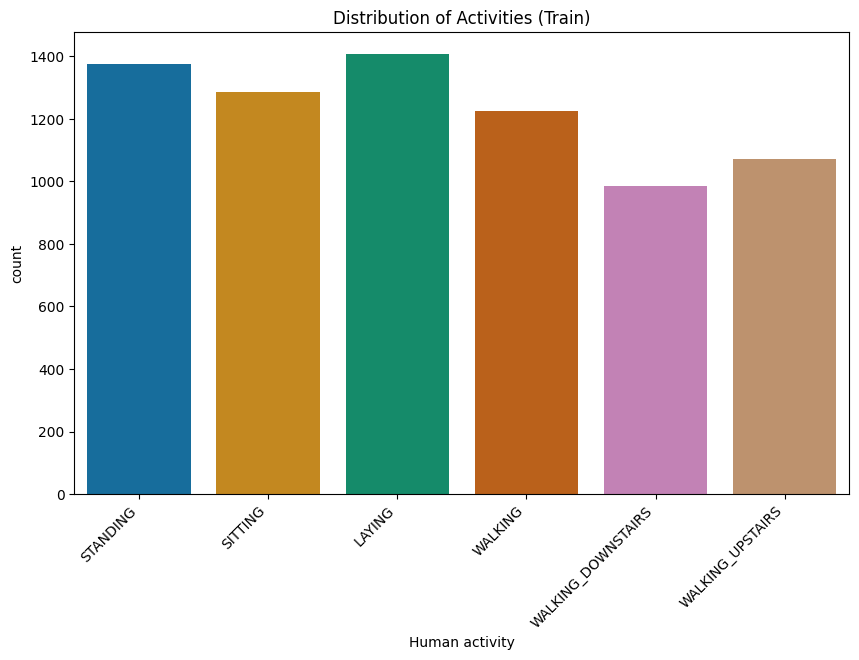

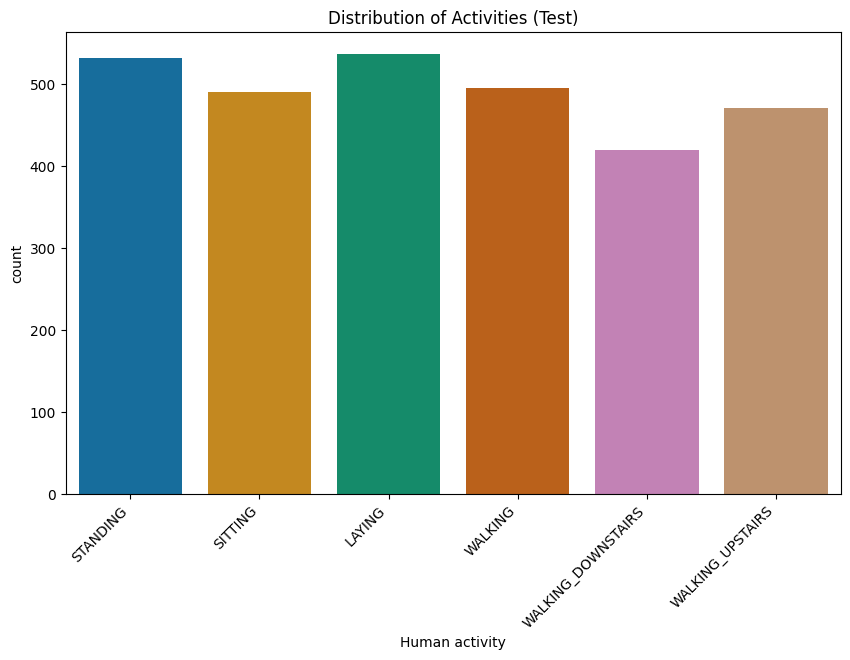

In [8]:
# count plot to show distribution of training labels
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x="activity", hue="activity", palette="colorblind", legend=False)
plt.title("Distribution of Activities (Train)")
plt.xticks(rotation=45, ha="right")  # rotate x-axis labels for better readability
plt.xlabel("Human activity")

# count plot to show distribution of test labels
plt.figure(figsize=(10, 6))
sns.countplot(data=test_df, x="activity", hue="activity", palette="colorblind", legend=False)
plt.title("Distribution of Activities (Test)")
plt.xticks(rotation=45, ha="right") # rotate x-axis labels for better readability
plt.xlabel("Human activity")

plt.show()

Selected feature distributions:

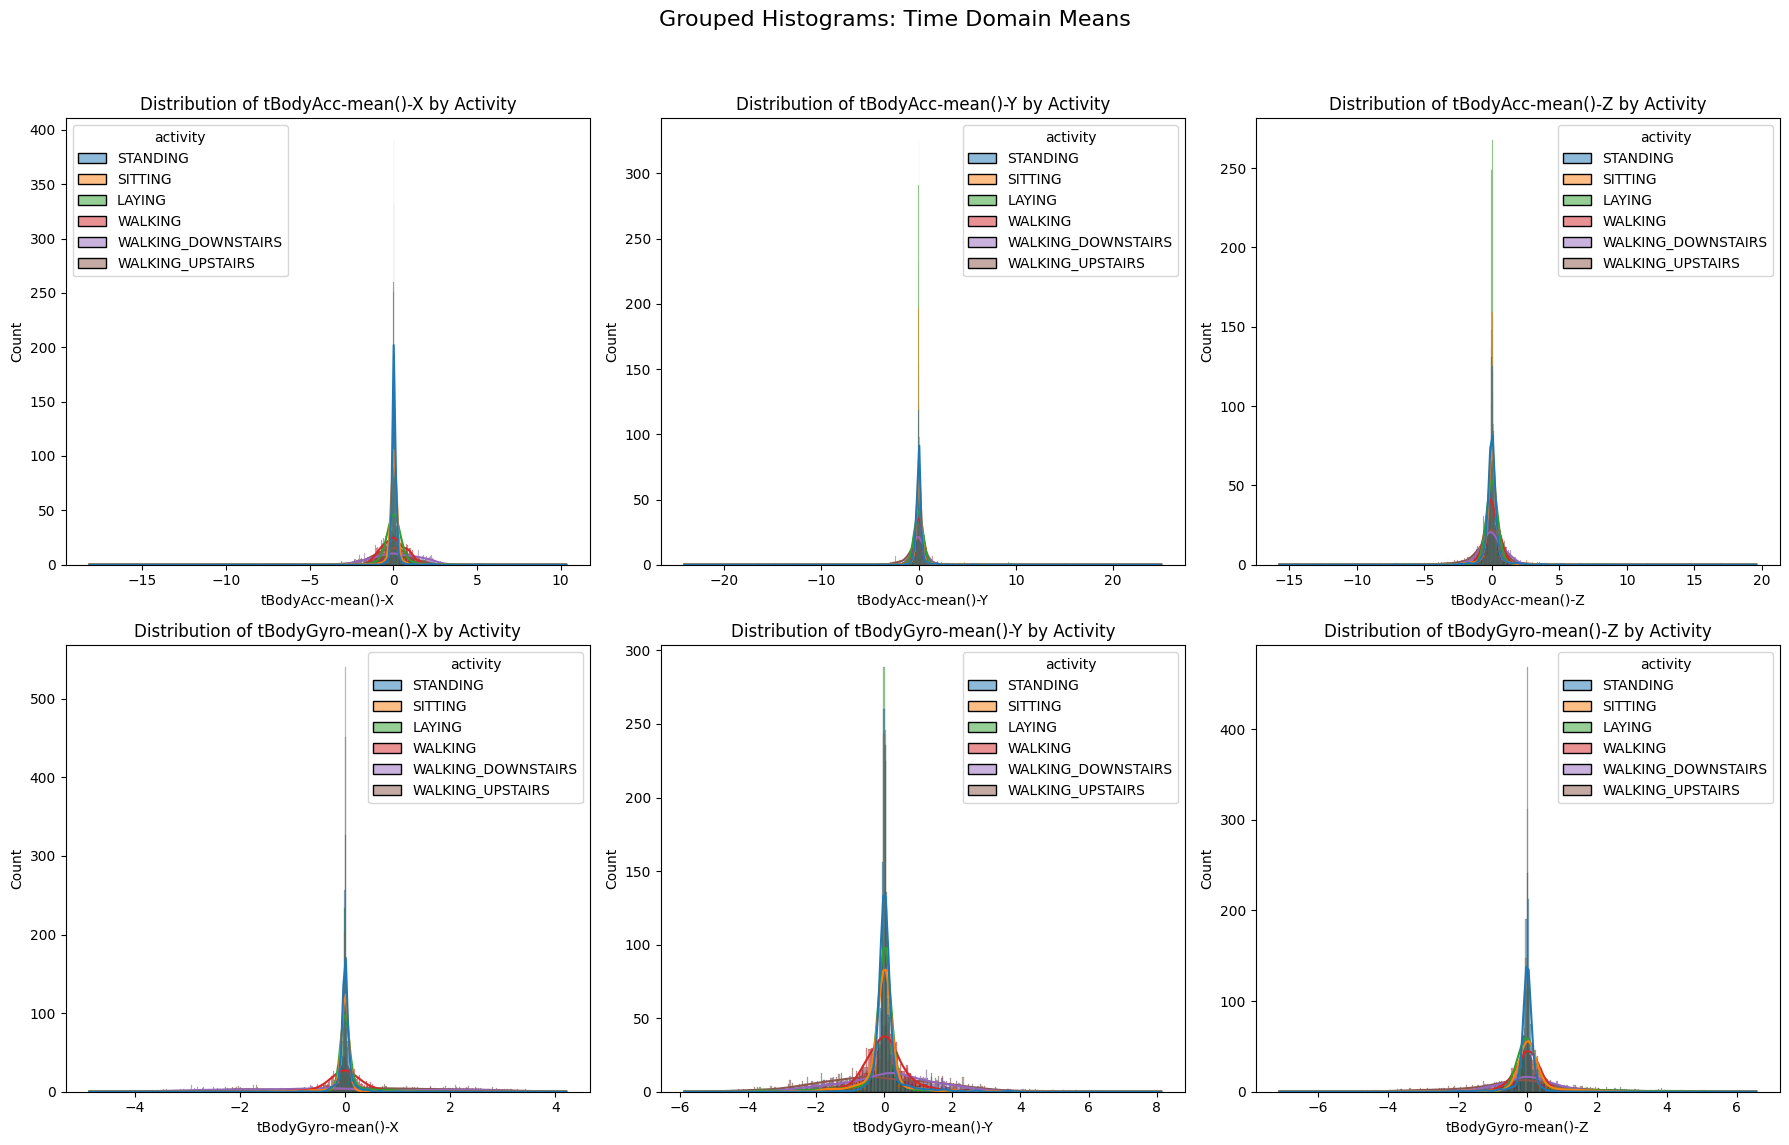

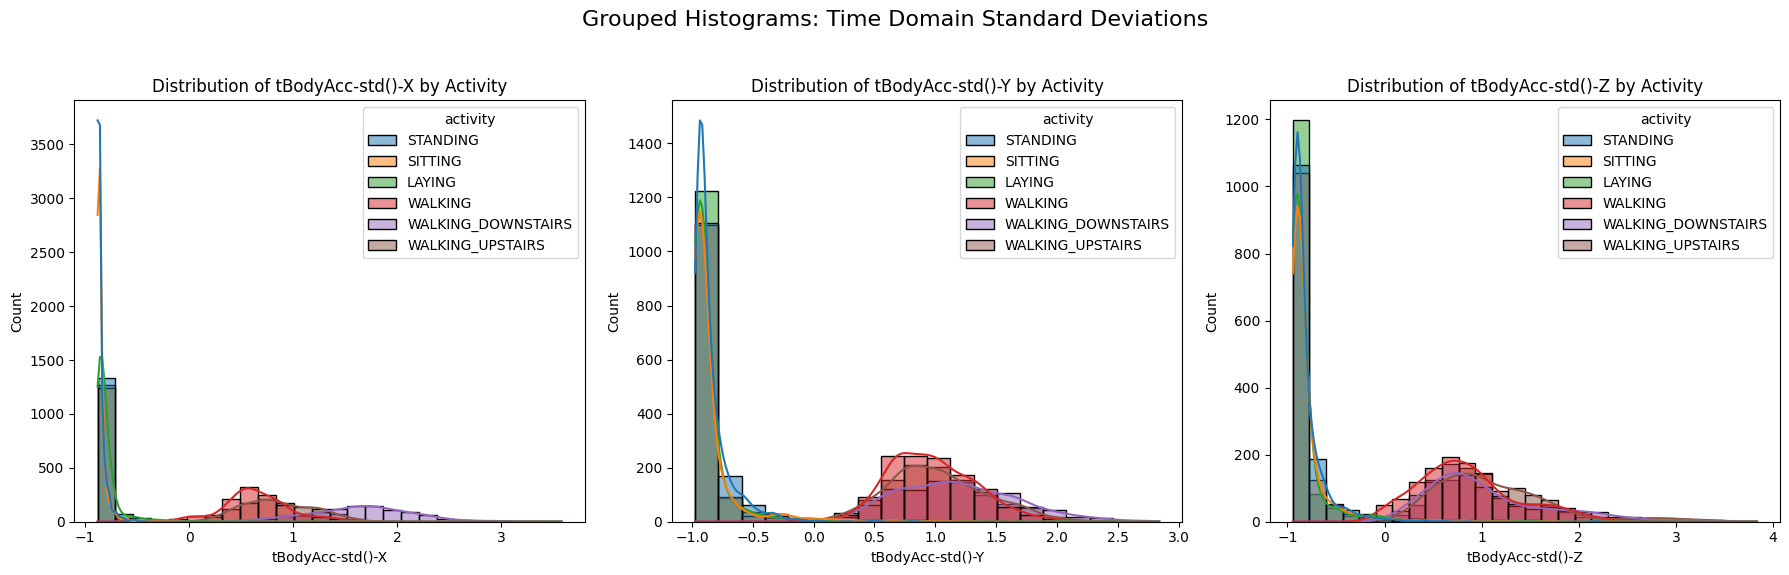

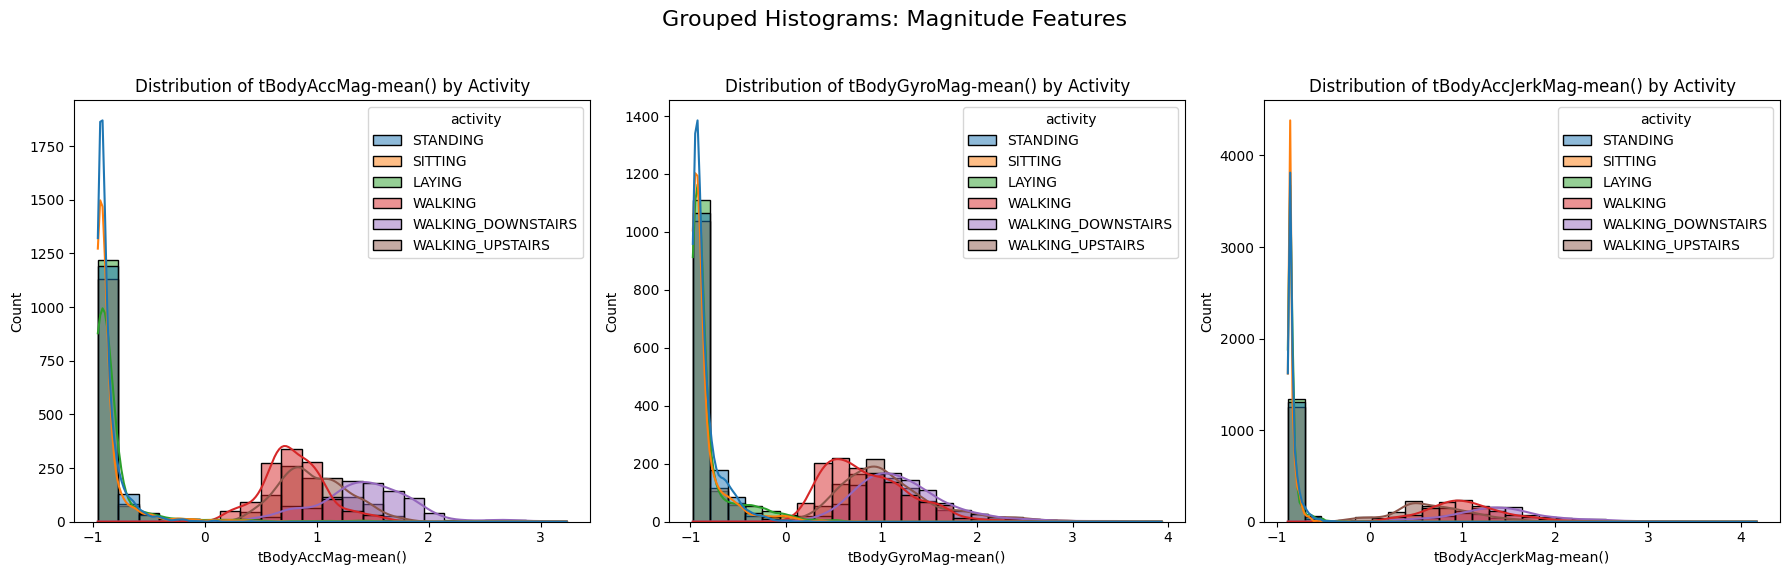

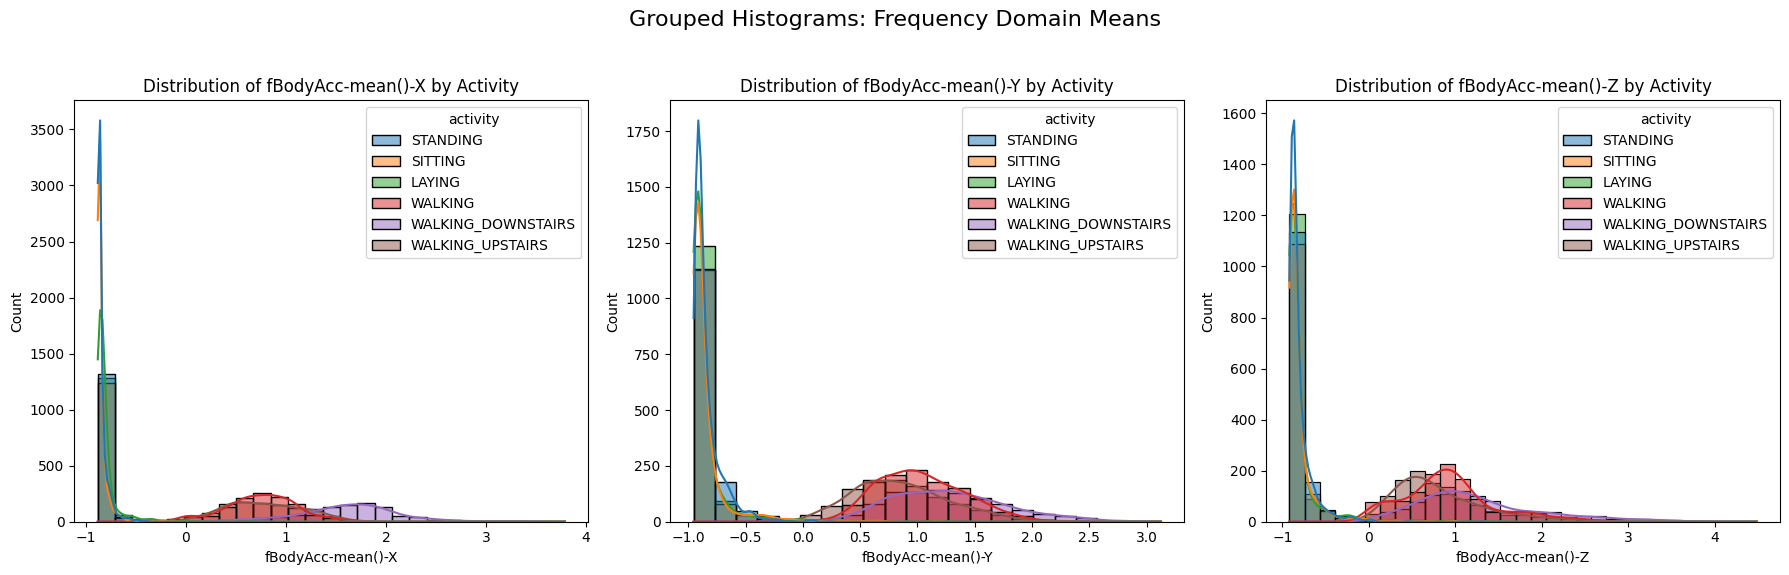

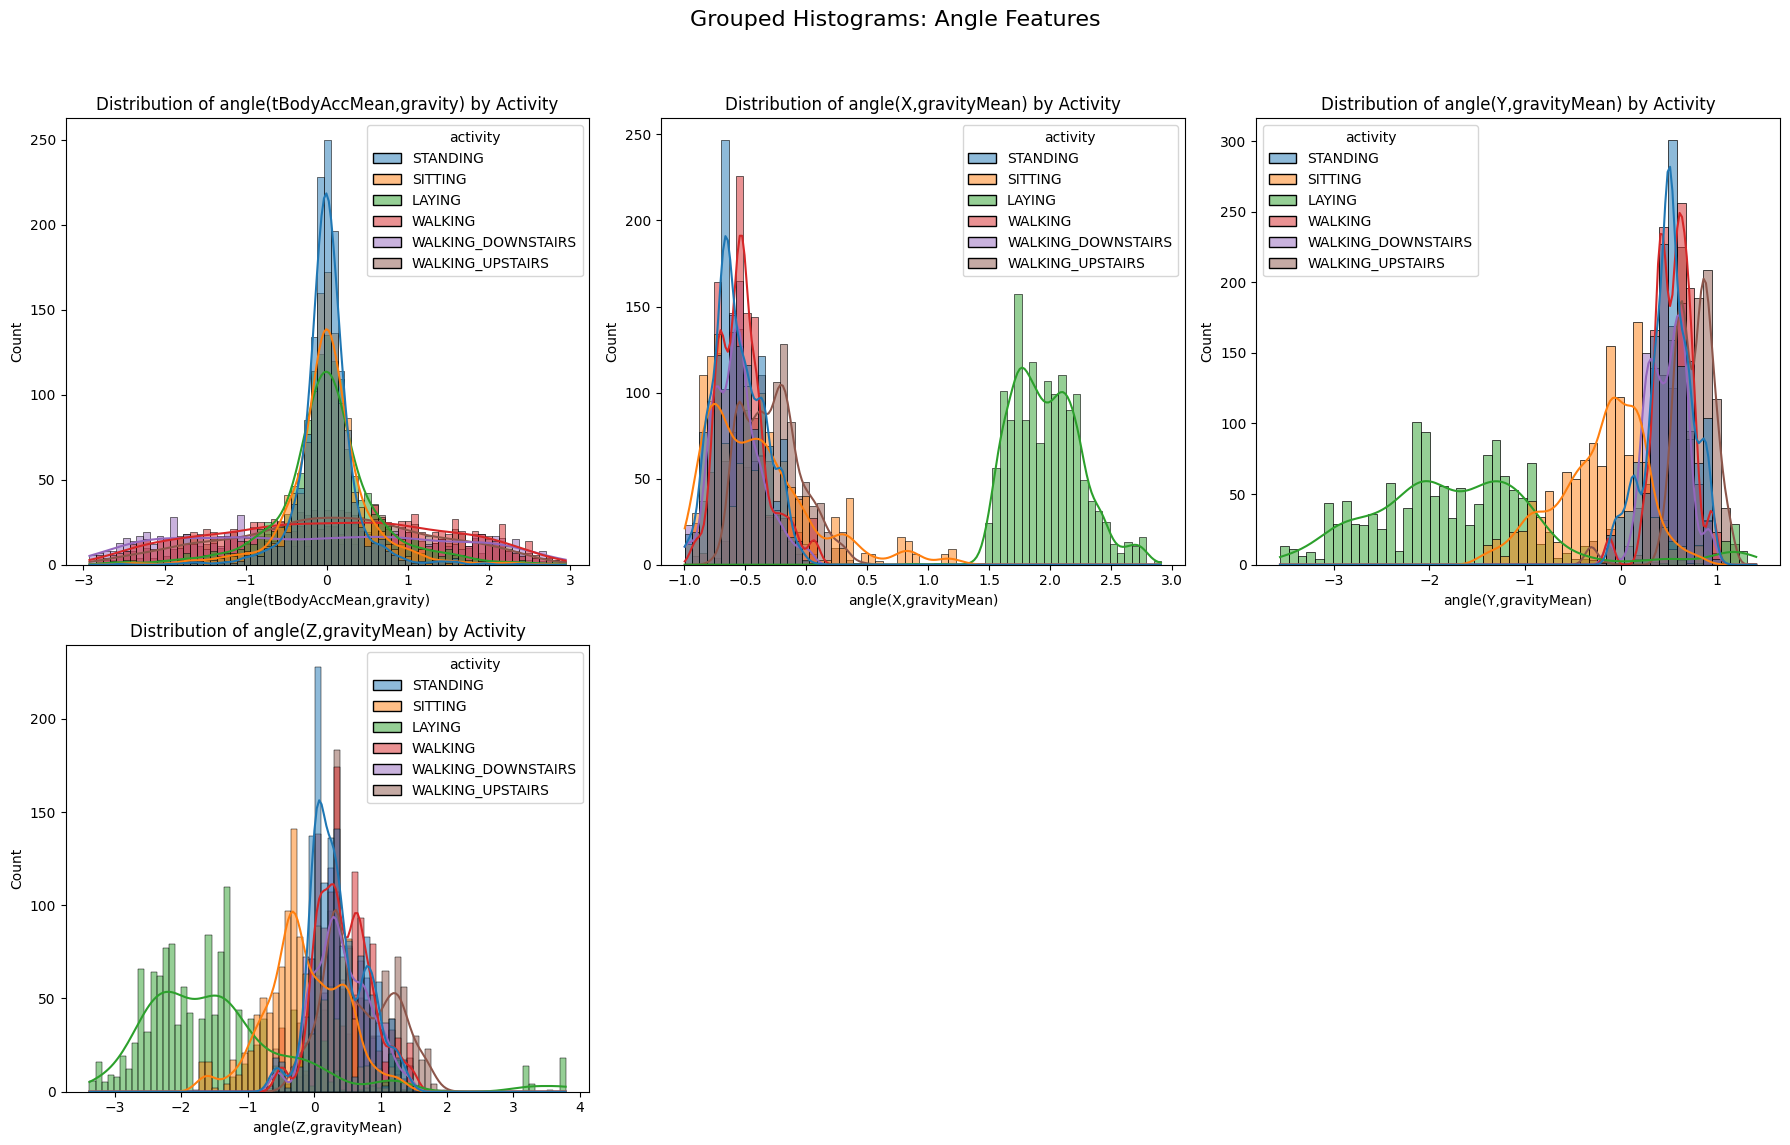

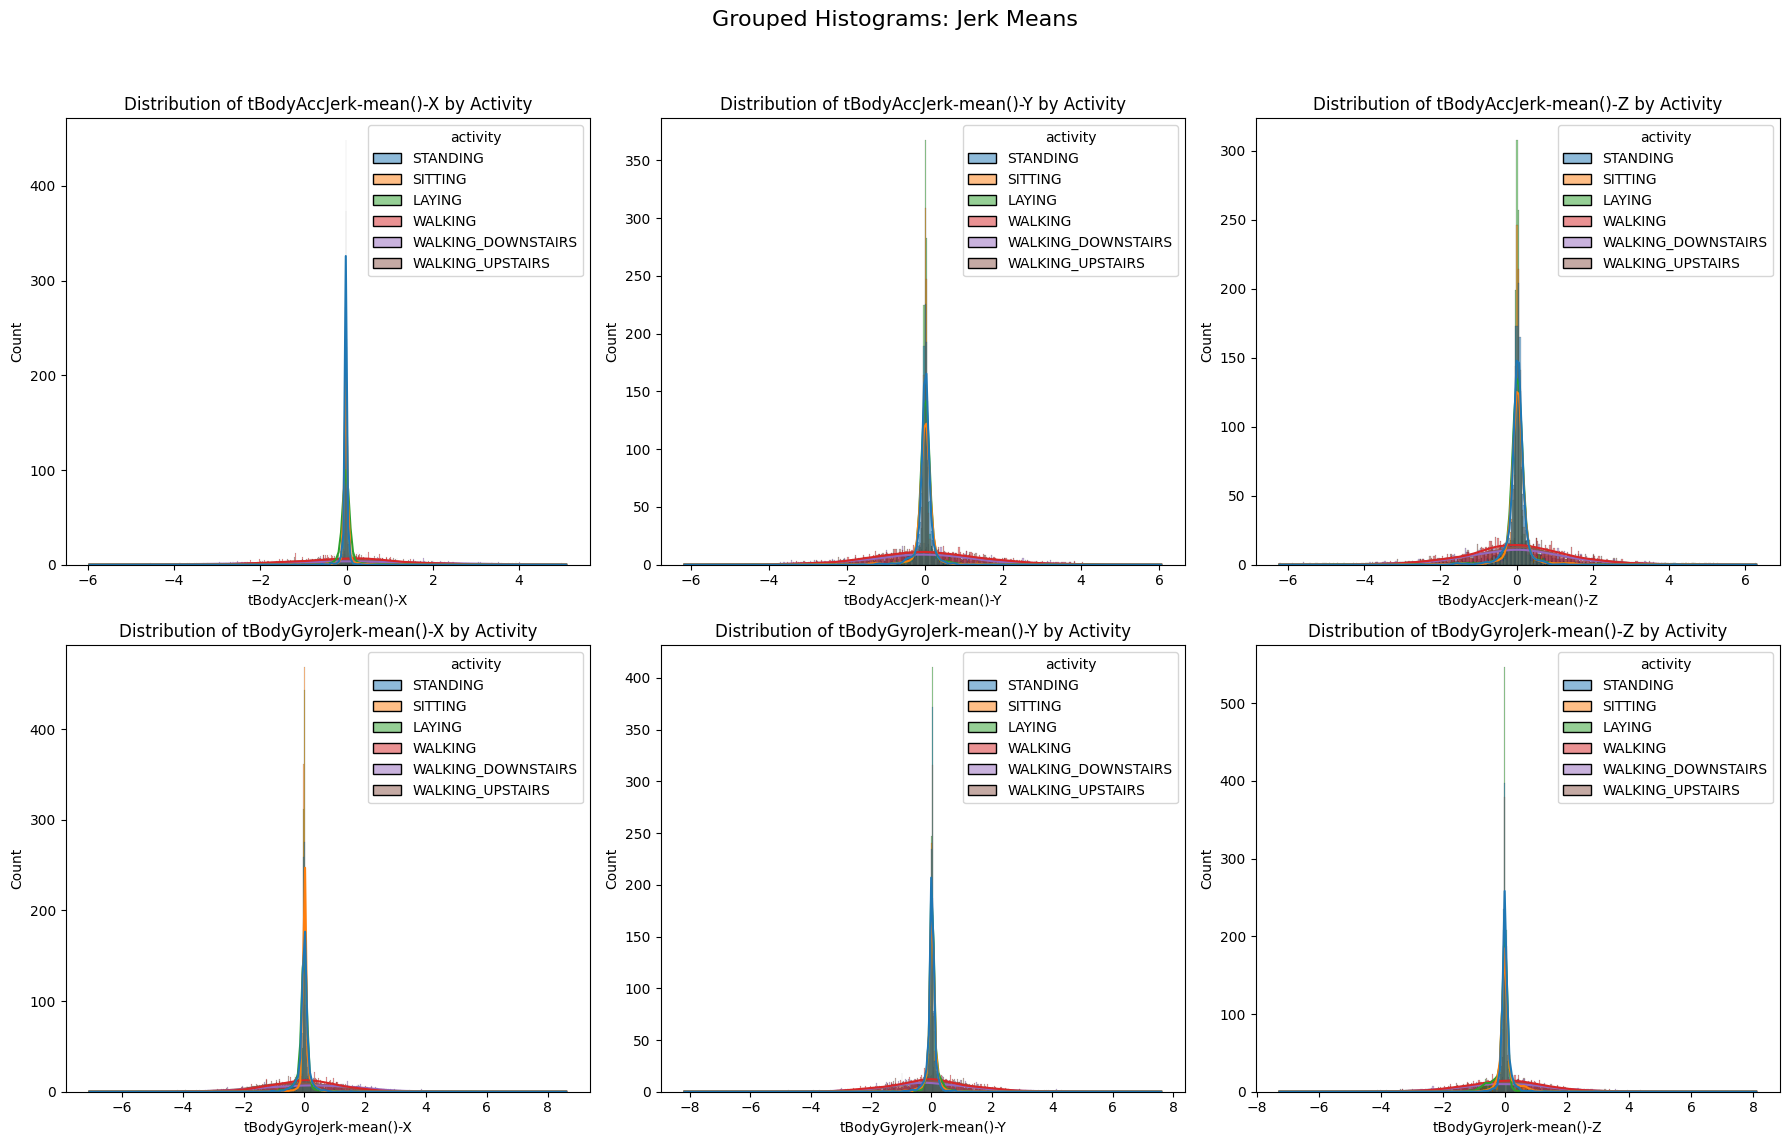

In [9]:
# selected feature groups
time_domain_means = ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
                     'tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z']
time_domain_stds = ['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z']
magnitude_features = ['tBodyAccMag-mean()', 'tBodyGyroMag-mean()', 'tBodyAccJerkMag-mean()']
frequency_domain_means = ['fBodyAcc-mean()-X', 'fBodyAcc-mean()-Y', 'fBodyAcc-mean()-Z']
angle_features = ['angle(tBodyAccMean,gravity)', 'angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)']
jerk_means = ['tBodyAccJerk-mean()-X', 'tBodyAccJerk-mean()-Y', 'tBodyAccJerk-mean()-Z',
              'tBodyGyroJerk-mean()-X', 'tBodyGyroJerk-mean()-Y', 'tBodyGyroJerk-mean()-Z']

feature_groups = {
    'Time Domain Means': time_domain_means,
    'Time Domain Standard Deviations': time_domain_stds,
    'Magnitude Features': magnitude_features,
    'Frequency Domain Means': frequency_domain_means,
    'Angle Features': angle_features,
    'Jerk Means' : jerk_means
}

# creating grouped histograms
for group_name, features in feature_groups.items():
    num_features = len(features)
    rows = (num_features + 2) // 3  # calculating rows for subplots
    cols = min(num_features, 3)     # calculating columns for subplots

    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = axes.flatten()  # flattening the axes array for easier iteration

    for i, feature in enumerate(features):
        sns.histplot(data=train_df, x=feature, hue='activity', kde=True, ax=axes[i])
        axes[i].set_title(f"Distribution of {feature} by Activity")

    # removing extra subplots if needed
    for j in range(num_features, rows * cols):
        fig.delaxes(axes[j])

    plt.suptitle(f"Grouped Histograms: {group_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # corrects the suptitle overlap
    plt.show()

As can be seen, we can classify human activity based on some features as there are clear separation (observe the magnitude and angle features). Other groups of features may also show separation on the human activity but the distribution of all the other groups of features cannot be shown here as it is impractical to show all histograms due to the high dimension of the dataset.

## Classification using Neural Network without dimensionality reduction

This section creates, fits, and evaluates a neural network model using all of the features of the dataset (thus, no dimensionality reduction).

In [10]:
# separating features and target
X_train = train_df.drop(['activity', 'subject'], axis=1).to_numpy()
y_train = train_df['activity'].to_numpy()
X_test = test_df.drop(['activity', 'subject'], axis=1).to_numpy()
y_test = test_df['activity'].to_numpy()

# verifying the separated features and target
print(f"X_train array (first row): {X_train[0, :]}")
print(f"X_train shape: {X_train.shape}")
print()
print(f"y_train array (first row): {y_train[0]}")
print(f"y_train shape: {y_train.shape}")
print()
print(f"X_test array (first row): {X_test[0, :]}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"y_test array (first row): {y_test[0]}")
print(f"y_test shape: {y_test.shape}")

X_train array (first row): [ 0.20064157 -0.0636826  -0.41962845 -0.86881389 -0.93944133 -0.73752941
 -0.85981668 -0.93901851 -0.76643665 -0.85603599 -0.92598454 -0.63737881
  0.90600869  0.86865566  0.73838305 -0.885916   -0.69303073 -0.77569634
 -0.67049557 -0.8339624  -0.92541678 -0.8075475  -0.64989794 -1.23822642
 -1.17999502  3.41252516 -3.87617503  1.63245448 -0.82156997  1.10007176
 -1.16830223  0.49870233 -0.34175676  0.9418653  -2.30437127  1.92773254
 -0.48226779  1.38089495  1.89952314  1.44227747  0.57917174 -0.40795505
  0.06169232 -0.26575265 -0.30641857  0.55324213 -0.25631866 -0.32876708
  0.41071019  0.56444743 -0.43825441  0.07486024  0.58772896 -0.39615055
 -0.06894335 -0.74089002  0.66311366 -0.55039182 -0.52947025 -0.22854336
 -0.35414612  0.24876141 -0.91072978 -0.46503661  2.01424495 -0.34949775
  0.1827801  -0.00904066 -0.16013948 -1.36705289  1.30359406 -1.20629389
  1.07253348 -2.08957597  2.07244699 -2.03169313  1.96524683  0.55041437
  0.76914333  1.27570673

Searching for the best neural network:

In [11]:
# defining an MLPClassifier
mlp = MLPClassifier(random_state=6, max_iter=1000)

# defining the hyperparameter distributions for RandomizedSearchCV
param_distributions = {
    'hidden_layer_sizes': [(randint(50, 200).rvs(),), # 1 hidden layer or
                           (randint(50, 200).rvs(), randint(50, 200).rvs())], # 2 hidden layers
    'activation': ['logistic', 'tanh', 'relu'], # logistic, tanh, or relu activation function for all nodes
    'solver': ['lbfgs', 'sgd', 'adam'] # optimizers
}

# performing RandomizedSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
random_search = RandomizedSearchCV(mlp, param_distributions, verbose=2, cv=skf, scoring='accuracy', random_state=6, n_jobs=-1)
random_search.fit(X_train, y_train)

# printing the best parameters and score
print()
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'solver': 'adam', 'hidden_layer_sizes': (173,), 'activation': 'relu'}
Best Score: 0.9885747582513632


Based on random search, the best parameters of the neural network (without using dimensionally-reduced data) are as follows:
* Optimizer: Adam
* Number of hidden layers: 1
* Number of neurons: 173
* Activation function for all neurons: ReLU

Evaluating the best neural network:

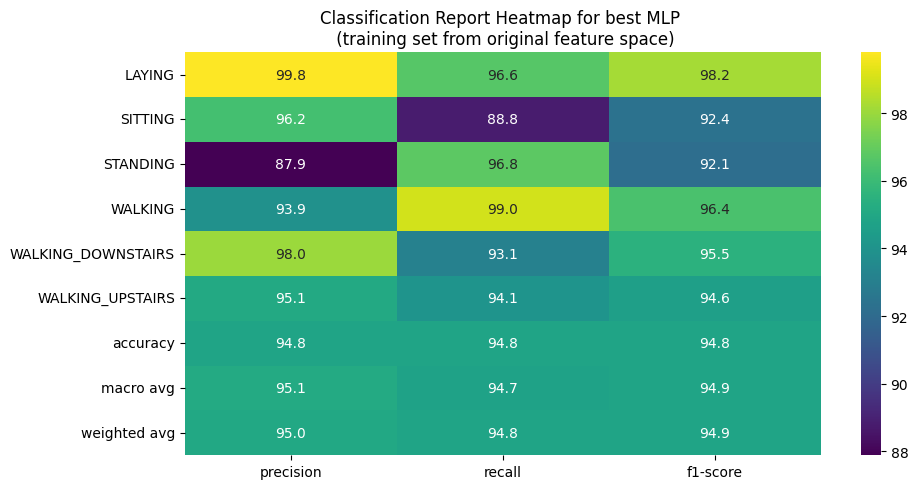

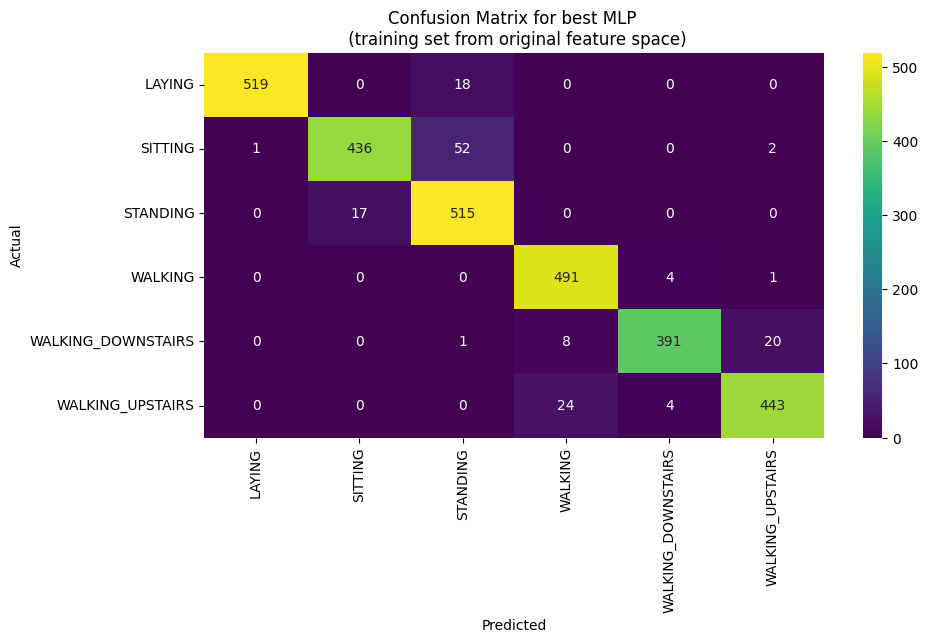

In [12]:
# evaluating the model on the test set
best_mlp = random_search.best_estimator_
y_pred = best_mlp.predict(X_test)

# classification report
report_nn1 = classification_report(y_test, y_pred, output_dict=True)
report_nn1_df = pd.DataFrame(report_nn1).transpose()

plt.figure(figsize=(10, 5))
sns.heatmap(report_nn1_df.iloc[:, :-1] * 100, annot=True, cmap='viridis', fmt=".1f")
plt.title("Classification Report Heatmap for best MLP \n (training set from original feature space)")
plt.tight_layout()
plt.show()

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for best MLP \n (training set from original feature space)')
plt.show()

Based on the classification report and confusion matrix, it seems that the we achieve pretty good results from the neural network created using all features in the original feature space. Looking at the test accuracy alone, the classification report shows about 95% while for the other metrics, the report also shows relatively high percentage values. With regards to misclassifications, the confusion matrix shows a few misses for sitting and standing, and among the three walking variants. Perhaps this is due to the former (sitting and standing) relatively similar in terms of the sensor values (both actions have the human as stationary) while the latter are also relatively similar ("walking downstairs" and "walking upstairs" are both "walking"). Overall, the trained neural network has shown relatively good results without any modification whatsoever (dimensionality reduction, feature engineering) on the original dataset.

## Classification using Neural Network with PCA

This section creates, fits, and evaluates a neural network model, this time, implementing dimensionality reduction (PCA) on the dataset.

Finding first the optimal number of principal components:

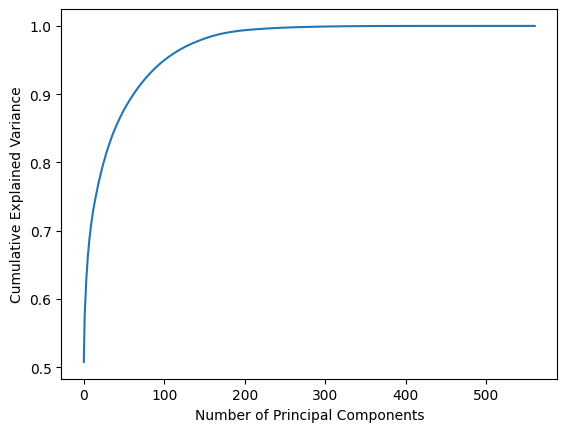

Number of components for 95% variance: 102


In [13]:
# applying PCA
pca = PCA()
pca.fit(X_train)

# calculating cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# plotting cumulative explained variance
plt.plot(cumulative_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# finding the number of components for a desired variance (e.g., 95%)
n_components = np.argmax(cumulative_variance >= 0.95) +1
print(f"Number of components for 95% variance: {n_components}")

Based from this, the optimal `n_components` is 102 as it explains 95% of the variance in the original dataset.

Applying PCA on the data with 102 `n_components`:

In [14]:
# applying PCA
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# checking shapes of PCA-reduced data
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

X_train_pca shape: (7352, 102)
X_test_pca shape: (2947, 102)


Training a new neural network with reduced data:

In [15]:
# defining a new MLPClassifier
mlp_pca = MLPClassifier(random_state=6, max_iter=1000)

# defining the hyperparameter distributions for RandomizedSearchCV
param_distributions = {
    'hidden_layer_sizes': [(randint(50, 200).rvs(),), # 1 hidden layer or
                           (randint(50, 200).rvs(), randint(50, 200).rvs())], # 2 hidden layers
    'activation': ['logistic', 'tanh', 'relu'], # logistic, tanh, or relu activation function for all nodes
    'solver': ['lbfgs', 'sgd', 'adam'] # optimizers
}

# performing RandomizedSearchCV
skf_pca = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
random_search_pca = RandomizedSearchCV(mlp_pca, param_distributions, verbose=2, cv=skf_pca, scoring='accuracy', random_state=6, n_jobs=-1)
random_search_pca.fit(X_train_pca, y_train)

# printing the best parameters and score
print()
print(f"Best Parameters: {random_search_pca.best_params_}")
print(f"Best Score: {random_search_pca.best_score_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'solver': 'adam', 'hidden_layer_sizes': (185, 128), 'activation': 'logistic'}
Best Score: 0.9815015006682483


Based on random search, the best parameters of the neural network (using dimensionally-reduced data) are as follows:
* Optimizer: Adam
* Number of hidden layers: 2
* Number of neurons: 185 for Hidden Layer 1, 128 for Hidden Layer 2
* Activation function for all neurons: Logistic/Sigmoid

Evaluating the new neural network trained with reduced data:

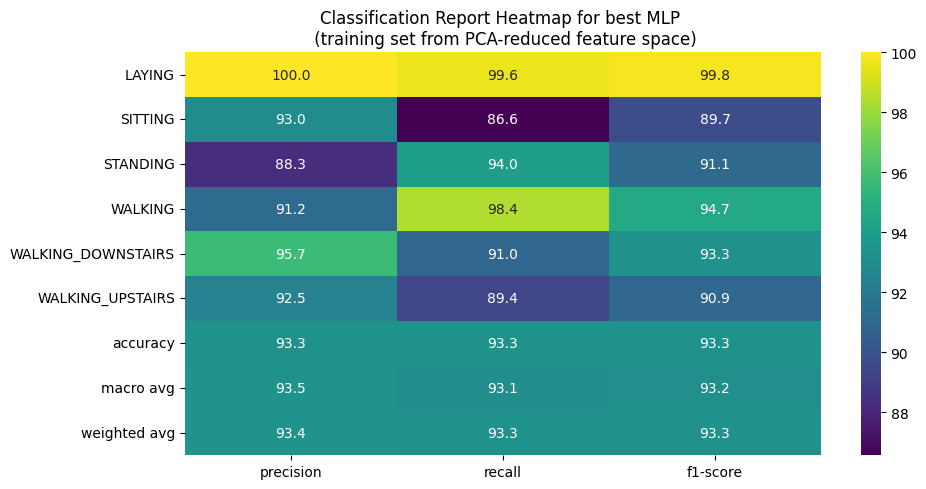

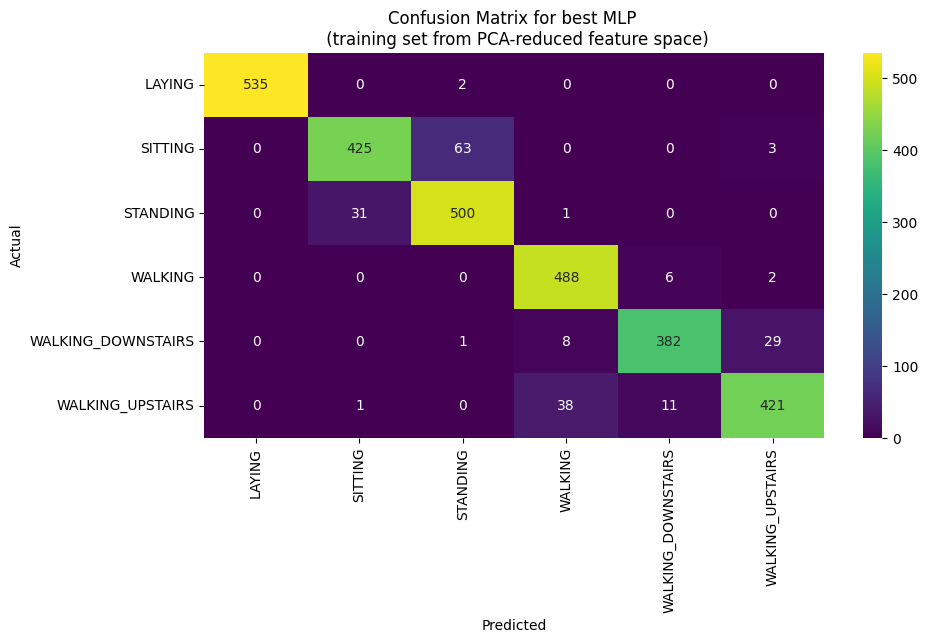

In [16]:
# evaluating the model on the test set
best_mlp_pca = random_search_pca.best_estimator_
y_pred_pca = best_mlp_pca.predict(X_test_pca)

# evaluating the model on the test set
best_mlp_pca = random_search_pca.best_estimator_
y_pred_pca = best_mlp_pca.predict(X_test_pca)

# classification report
report_nn2 = classification_report(y_test, y_pred_pca, output_dict=True)
report_nn2_df = pd.DataFrame(report_nn2).transpose()

plt.figure(figsize=(10, 5))
sns.heatmap(report_nn2_df.iloc[:, :-1] * 100, annot=True, cmap='viridis', fmt=".1f")
plt.title("Classification Report Heatmap for best MLP \n (training set from PCA-reduced feature space)")
plt.tight_layout()
plt.show()

# confusion matrix
cm = confusion_matrix(y_test, y_pred_pca, labels=np.unique(y_test))

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for best MLP \n (training set from PCA-reduced feature space)')
plt.show()

With the PCA-reduced data, the trained neural network also shows good result, although with relatively decreased percentage points in terms of test accuracy (about 94%). However, with the PCA-reduced data, some metrics increased, such as the recall and F1-score for the "laying" class. As for the confusion matrix, the explanation for the misclassifications follow a similar trend as before: there are misclassifications between sitting and standing, and among the three walking variants due to the similarities among the two groups. Overall, although with a decreased test accuracy, the new neural network based on the PCA-reduced dataset still shows relatively good results.

## Summary

* Two neural networks are trained: one using the entire feature space and the other, using a PCA-reduced feature space.
* The best neural networks are obtained via a random hyperparameter search, with the former needing only one hidden layer while the latter needing two hidden layers.
* Results show that the two neural networks are comparable, with the latter neural network (trained with PCA-reduced data) having a relatively less test accuracy (about 94%) than the one trained with the original feature space (about 95%). The results are still pretty close and it cannot be said that one neural network is clearly better than the other. However, it can be said that, even though the data is not reduced, a neural network can still exhibit good results despite the high dimension of the input data. Perhaps this is because, internally, a neural network performs its own "regularization" that "reduces" the dimension of the data. This shows that a neural network is powerful on its own: without the use of feature engineering or dimensionality reduction, a neural network can exhibit good results.
* The results from the two trained neural networks are comparable to the SVM results from the paper accompanying the HAR dataset ("<a href="https://www.semanticscholar.org/paper/A-Public-Domain-Dataset-for-Human-Activity-using-Anguita-Ghio/83de43bc849ad3d9579ccf540e6fe566ef90a58e">A Public Domain Dataset for Human Activity Recognition using Smartphones</a>"). The paper reports a 96% test accuracy that is close to the results obtained from the experiments.